In [1]:
# Cell 1: Import required libraries

import pandas as pd
import numpy as np

In [2]:
# Cell 2: Load the heart dataset

df = pd.read_csv("heart.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Check dataset size
print("Dataset shape:", df.shape)

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21


Dataset shape: (1025, 14)


In [3]:
# Cell 3: Clean column names and remove unnecessary columns

# Remove spaces from column names and make them consistent
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop unwanted index columns if they exist
unwanted_cols = [col for col in df.columns if "unnamed" in col]

if len(unwanted_cols) > 0:
    df = df.drop(columns=unwanted_cols)
    print("Removed columns:", unwanted_cols)
else:
    print("No unwanted index columns found.")

# Display updated columns
print("Updated column names:")
print(df.columns.tolist())

No unwanted index columns found.
Updated column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [4]:
# Cell 4: Check missing values and duplicate rows

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows before removing:", df.duplicated().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

Duplicate rows before removing: 55


In [5]:
# Cell 5: Remove duplicate rows

df = df.drop_duplicates()

print("Duplicate rows after removing:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows after removing: 0
Dataset shape after removing duplicates: (970, 14)


In [6]:
# Cell 6: Convert decimal target into binary classification target

# Original target is a decimal risk score
print("Original target minimum value:", df["target"].min())
print("Original target maximum value:", df["target"].max())
print("Number of unique target values:", df["target"].nunique())

# Create new classification target
# 0 = low heart disease risk
# 1 = high heart disease risk
df["target_class"] = df["target"].apply(lambda x: 1 if x >= 0.5 else 0)

print("\nNew target class distribution:")
print(df["target_class"].value_counts())

# Final dataset check
print("\nFinal dataset shape:", df.shape)
display(df.head())

# Optional: save the cleaned dataset
df.to_csv("heart_preprocessed_basic.csv", index=False)
print("\nCleaned dataset saved as heart_preprocessed_basic.csv")

Original target minimum value: 0.1
Original target maximum value: 0.9
Number of unique target values: 52

New target class distribution:
target_class
1    493
0    477
Name: count, dtype: int64

Final dataset shape: (970, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_class
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21,0



Cleaned dataset saved as heart_preprocessed_basic.csv


In [7]:
# Cell 1: Import libraries for EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check first few rows
display(df.head())

# Basic dataset information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nBasic statistical summary:")
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_class
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21,0


Dataset shape: (970, 15)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'target_class']

Basic statistical summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_class
count,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000
mean,54.400000,0.695876,0.946392,131.722680,245.648454,0.150515,0.536082,149.108247,0.336082,1.070309,1.385567,0.759794,2.335052,0.533247,0.508247
std,9.112461,0.460273,1.032602,17.584776,51.771299,0.357760,0.527115,23.111067,0.472611,1.175518,0.617761,1.032512,0.623009,0.285856,0.500190
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.260000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,239.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,0.700000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.000000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,0.810000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,0.900000,1.000000


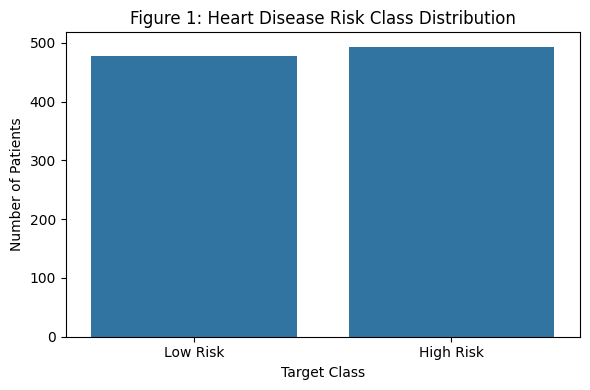

Target class counts:
target_class
1    493
0    477
Name: count, dtype: int64


In [8]:
# Cell 2: Plot target class distribution
# This shows how many patients are in low-risk and high-risk heart disease groups.

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target_class")

plt.title("Figure 1: Heart Disease Risk Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Low Risk", "High Risk"])

plt.tight_layout()
plt.show()

print("Target class counts:")
print(df["target_class"].value_counts())

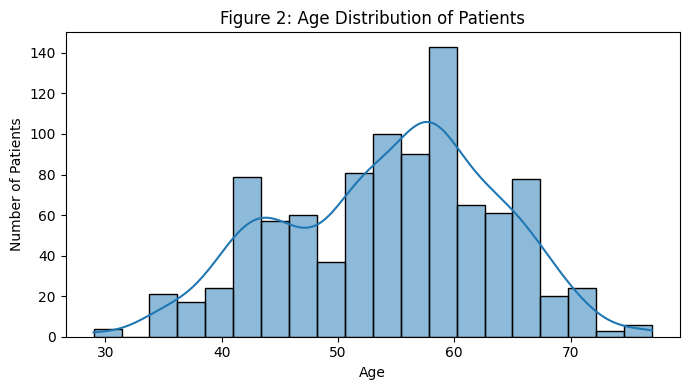

In [9]:
# Cell 3: Plot age distribution
# This shows the age spread of patients in the dataset.

plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="age", bins=20, kde=True)

plt.title("Figure 2: Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

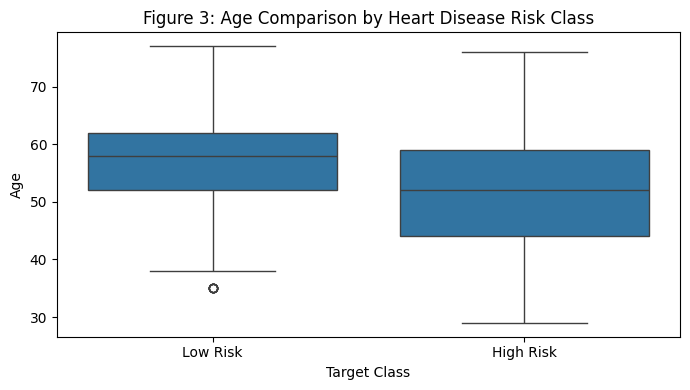

In [10]:
# Cell 4: Compare age with heart disease risk
# This helps to see whether high-risk patients are more common in certain age groups.

plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="target_class", y="age")

plt.title("Figure 3: Age Comparison by Heart Disease Risk Class")
plt.xlabel("Target Class")
plt.ylabel("Age")
plt.xticks([0, 1], ["Low Risk", "High Risk"])

plt.tight_layout()
plt.show()

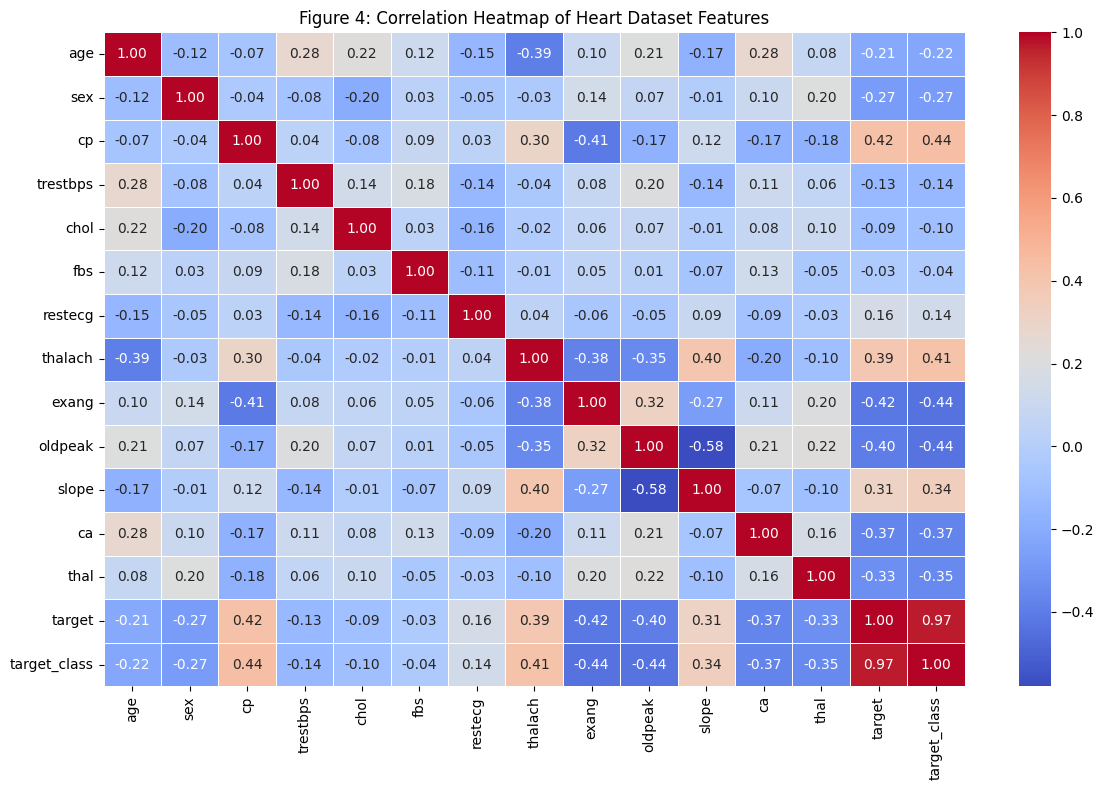

In [11]:
# Cell 5: Correlation heatmap
# This shows relationships between numerical features.

plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Figure 4: Correlation Heatmap of Heart Dataset Features")

plt.tight_layout()
plt.show()

In [12]:
# Cell 1: Import libraries for train-test split and scaling

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [13]:
# Cell 2: Check and prepare the target column

# If target_class is not already created, create it from the original target column
if "target_class" not in df.columns:
    df["target_class"] = df["target"].apply(lambda x: 1 if x >= 0.5 else 0)

print("Target column used for prediction: target_class")

print("\nTarget class distribution:")
print(df["target_class"].value_counts())

display(df.head())

Target column used for prediction: target_class

Target class distribution:
target_class
1    493
0    477
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_class
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21,0


In [14]:
# Cell 3: Separate features and target variable

# Drop original target also, because it was used to create target_class
X = df.drop(columns=["target", "target_class"])

# Target variable
y = df["target_class"]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nInput feature columns:")
print(X.columns.tolist())

Feature dataset shape: (970, 13)
Target dataset shape: (970,)

Input feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [15]:
# Cell 4: Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (776, 13)
X_test shape: (194, 13)
y_train shape: (776,)
y_test shape: (194,)

Training target distribution:
target_class
1    394
0    382
Name: count, dtype: int64

Testing target distribution:
target_class
1    99
0    95
Name: count, dtype: int64


In [16]:
# Cell 5: Scale the feature values using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed successfully.
X_train_scaled shape: (776, 13)
X_test_scaled shape: (194, 13)


In [17]:
# Cell 6: Convert scaled arrays into DataFrames

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("First 5 rows of scaled training data:")
display(X_train_scaled.head())

print("First 5 rows of scaled testing data:")
display(X_test_scaled.head())

First 5 rows of scaled training data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
172,0.180597,0.669150,0.053624,-0.666736,-0.104252,-0.4107,0.841762,0.865792,-0.695520,-0.910523,-2.261572,-0.733094,-0.548701
844,0.614140,0.669150,-0.914105,0.460592,0.896839,-0.4107,-1.046120,0.909017,-0.695520,0.122091,-0.632064,1.156876,1.046026
509,0.072211,-1.494434,-0.914105,2.715249,1.539048,-0.4107,2.729644,-1.381936,1.437774,2.015216,-0.632064,-0.733094,-0.548701
867,-1.445192,0.669150,0.053624,-1.230401,-0.198694,-0.4107,0.841762,0.174183,-0.695520,-0.910523,0.997444,-0.733094,-0.548701
759,0.722526,-1.494434,-0.914105,-0.103072,1.595714,-0.4107,-1.046120,0.865792,-0.695520,-0.910523,0.997444,-0.733094,-0.548701


First 5 rows of scaled testing data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
786,1.372842,0.66915,-0.914105,-0.384904,0.160187,2.434866,0.841762,0.606439,-0.695520,-0.738421,-0.632064,1.156876,1.046026
592,1.698000,0.66915,1.021353,1.587921,0.443515,-0.410700,0.841762,-1.598063,1.437774,1.584960,-0.632064,0.211891,1.046026
571,0.614140,0.66915,-0.914105,0.742424,0.689065,-0.410700,-1.046120,-0.301298,1.437774,1.498909,-0.632064,1.156876,1.046026
840,1.698000,0.66915,-0.914105,0.742424,-1.350893,-0.410700,0.841762,-1.036132,1.437774,1.326807,-2.261572,-0.733094,1.046026
411,0.180597,0.66915,-0.914105,-0.384904,0.065745,2.434866,-1.046120,-0.214846,1.437774,0.122091,-0.632064,0.211891,-0.548701


In [18]:
# Cell 1: Import model and evaluation libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Empty lists/dictionaries to store model results
model_results = []
roc_data = {}

print("Libraries imported successfully.")

Libraries imported successfully.


Decision Tree Parameters:
DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.84        95
           1       0.89      0.77      0.83        99

    accuracy                           0.84       194
   macro avg       0.84      0.84      0.83       194
weighted avg       0.84      0.84      0.83       194



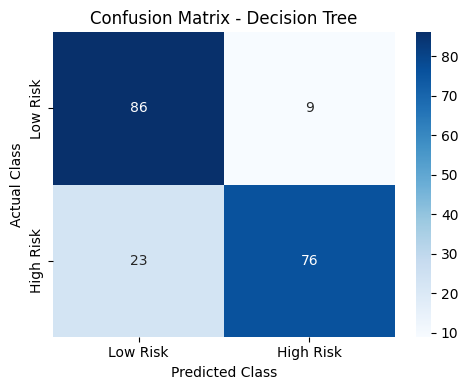

Decision Tree AUC Score: 0.9321


In [19]:
# Cell 2: Train and evaluate Decision Tree model

# Decision Tree parameters:
# criterion = "gini" means the model uses Gini impurity to split nodes
# max_depth = 4 controls tree depth and reduces overfitting
# min_samples_split = 10 means a node needs at least 10 samples to split
# random_state = 42 gives reproducible results

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test_scaled)
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation scores
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)
dt_auc = roc_auc_score(y_test, dt_prob)

# Store result
model_results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1,
    "AUC Score": dt_auc
})

roc_data["Decision Tree"] = dt_prob

print("Decision Tree Parameters:")
print(dt_model)

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred, zero_division=0))

# Confusion matrix
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("Decision Tree AUC Score:", round(dt_auc, 4))

SVM Parameters:
SVC(probability=True, random_state=42)

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        95
           1       0.93      0.96      0.95        99

    accuracy                           0.94       194
   macro avg       0.94      0.94      0.94       194
weighted avg       0.94      0.94      0.94       194



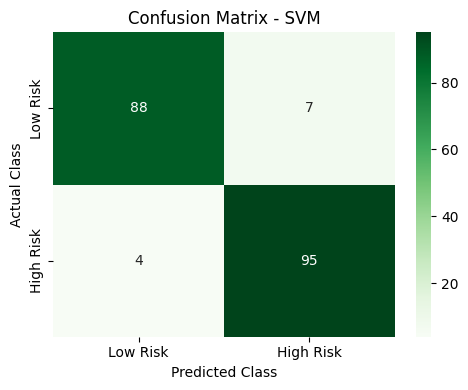

SVM AUC Score: 0.986


In [20]:
# Cell 3: Train and evaluate SVM model

# SVM parameters:
# kernel = "rbf" allows the model to learn non-linear patterns
# C = 1.0 controls regularisation strength
# gamma = "scale" automatically sets kernel coefficient
# probability = True is required for ROC-AUC curve
# random_state = 42 gives reproducible results

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation scores
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, zero_division=0)
svm_recall = recall_score(y_test, svm_pred, zero_division=0)
svm_f1 = f1_score(y_test, svm_pred, zero_division=0)
svm_auc = roc_auc_score(y_test, svm_prob)

# Store result
model_results.append({
    "Model": "SVM",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1,
    "AUC Score": svm_auc
})

roc_data["SVM"] = svm_prob

print("SVM Parameters:")
print(svm_model)

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred, zero_division=0))

# Confusion matrix
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("SVM AUC Score:", round(svm_auc, 4))

XGBoost Parameters:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        95
           1       0.98      0.96      0.97        99

    accura

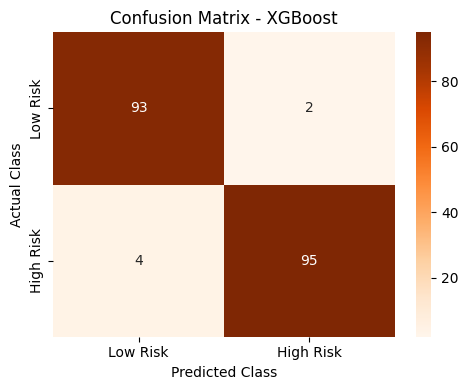

XGBoost AUC Score: 0.9957


In [21]:
# Cell 4: Train and evaluate XGBoost model

# XGBoost parameters:
# n_estimators = 100 means the model builds 100 trees
# learning_rate = 0.1 controls how fast the model learns
# max_depth = 3 controls tree depth and helps reduce overfitting
# subsample = 0.8 uses 80% of data for each tree
# colsample_bytree = 0.8 uses 80% of features for each tree
# eval_metric = "logloss" is suitable for binary classification

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation scores
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_auc = roc_auc_score(y_test, xgb_prob)

# Store result
model_results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "AUC Score": xgb_auc
})

roc_data["XGBoost"] = xgb_prob

print("XGBoost Parameters:")
print(xgb_model)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, zero_division=0))

# Confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("XGBoost AUC Score:", round(xgb_auc, 4))

In [22]:
# Cell 5: Compare model performance

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by="AUC Score", ascending=False)

display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_auc = results_df.iloc[0]["AUC Score"]

print("Best Model:", best_model_name)
print("Best AUC Score:", round(best_auc, 4))

,Model,Accuracy,Precision,Recall,F1 Score,AUC Score
2,XGBoost,0.969072,0.979381,0.959596,0.969388,0.995747
1,SVM,0.943299,0.931373,0.959596,0.945274,0.985965
0,Decision Tree,0.835052,0.894118,0.767677,0.826087,0.932111


Best Model: XGBoost
Best AUC Score: 0.9957


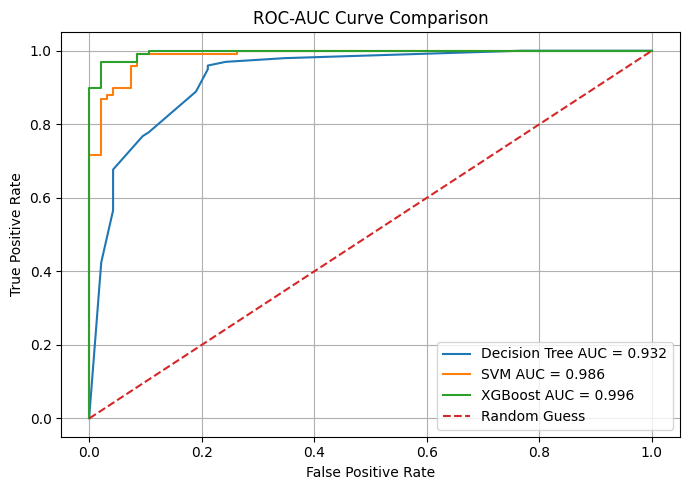

In [23]:
# Cell 6: Plot ROC-AUC curves for all models

plt.figure(figsize=(7, 5))

for model_name, y_prob in roc_data.items():

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC = {auc_score:.3f}"
    )

# Random guess line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC-AUC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
# Cell 1: Import libraries for hyperparameter tuning

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Store tuned model results
tuned_results = []
tuned_roc_data = {}

print("Hyperparameter tuning libraries imported successfully.")

Hyperparameter tuning libraries imported successfully.


Best Decision Tree Parameters:
{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 8, 'criterion': 'gini'}

Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        95
           1       1.00      0.98      0.99        99

    accuracy                           0.99       194
   macro avg       0.99      0.99      0.99       194
weighted avg       0.99      0.99      0.99       194



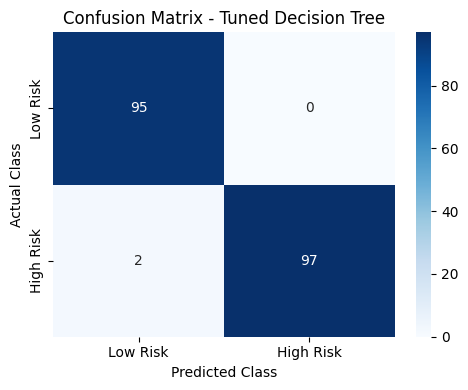

Tuned Decision Tree AUC Score: 0.9996


In [25]:
# Cell 2: Hyperparameter tuning for Decision Tree

from sklearn.tree import DecisionTreeClassifier

# Base Decision Tree model
dt_base = DecisionTreeClassifier(random_state=42)

# Hyperparameter search space
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8]
}

# RandomizedSearchCV setup
dt_random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=dt_params,
    n_iter=15,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Train using only training data
dt_random_search.fit(X_train_scaled, y_train)

# Best tuned model
best_dt = dt_random_search.best_estimator_

# Predictions
dt_tuned_pred = best_dt.predict(X_test_scaled)
dt_tuned_prob = best_dt.predict_proba(X_test_scaled)[:, 1]

# Evaluation
dt_tuned_accuracy = accuracy_score(y_test, dt_tuned_pred)
dt_tuned_precision = precision_score(y_test, dt_tuned_pred, zero_division=0)
dt_tuned_recall = recall_score(y_test, dt_tuned_pred, zero_division=0)
dt_tuned_f1 = f1_score(y_test, dt_tuned_pred, zero_division=0)
dt_tuned_auc = roc_auc_score(y_test, dt_tuned_prob)

# Store results
tuned_results.append({
    "Model": "Tuned Decision Tree",
    "Accuracy": dt_tuned_accuracy,
    "Precision": dt_tuned_precision,
    "Recall": dt_tuned_recall,
    "F1 Score": dt_tuned_f1,
    "AUC Score": dt_tuned_auc
})

tuned_roc_data["Tuned Decision Tree"] = dt_tuned_prob

print("Best Decision Tree Parameters:")
print(dt_random_search.best_params_)

print("\nTuned Decision Tree Classification Report:")
print(classification_report(y_test, dt_tuned_pred, zero_division=0))

# Confusion matrix
dt_cm = confusion_matrix(y_test, dt_tuned_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("Tuned Decision Tree AUC Score:", round(dt_tuned_auc, 4))

Best SVM Parameters:
{'kernel': 'rbf', 'gamma': 'scale', 'degree': 2, 'C': 10}

Tuned SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        95
           1       0.99      1.00      0.99        99

    accuracy                           0.99       194
   macro avg       0.99      0.99      0.99       194
weighted avg       0.99      0.99      0.99       194



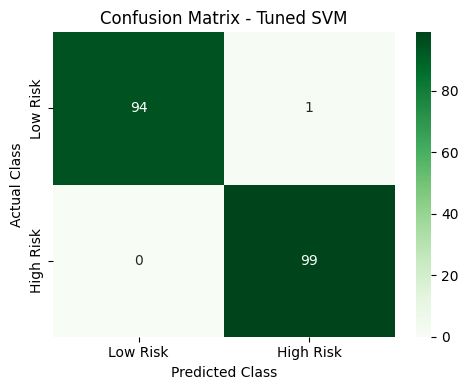

Tuned SVM AUC Score: 1.0


In [26]:
# Cell 3: Hyperparameter tuning for SVM

from sklearn.svm import SVC

# Base SVM model
svm_base = SVC(
    probability=True,
    random_state=42
)

# Hyperparameter search space
svm_params = {
    "C": [0.1, 1, 5, 10, 20],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"],
    "degree": [2, 3, 4]
}

# RandomizedSearchCV setup
svm_random_search = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=svm_params,
    n_iter=15,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Train using only training data
svm_random_search.fit(X_train_scaled, y_train)

# Best tuned model
best_svm = svm_random_search.best_estimator_

# Predictions
svm_tuned_pred = best_svm.predict(X_test_scaled)
svm_tuned_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

# Evaluation
svm_tuned_accuracy = accuracy_score(y_test, svm_tuned_pred)
svm_tuned_precision = precision_score(y_test, svm_tuned_pred, zero_division=0)
svm_tuned_recall = recall_score(y_test, svm_tuned_pred, zero_division=0)
svm_tuned_f1 = f1_score(y_test, svm_tuned_pred, zero_division=0)
svm_tuned_auc = roc_auc_score(y_test, svm_tuned_prob)

# Store results
tuned_results.append({
    "Model": "Tuned SVM",
    "Accuracy": svm_tuned_accuracy,
    "Precision": svm_tuned_precision,
    "Recall": svm_tuned_recall,
    "F1 Score": svm_tuned_f1,
    "AUC Score": svm_tuned_auc
})

tuned_roc_data["Tuned SVM"] = svm_tuned_prob

print("Best SVM Parameters:")
print(svm_random_search.best_params_)

print("\nTuned SVM Classification Report:")
print(classification_report(y_test, svm_tuned_pred, zero_division=0))

# Confusion matrix
svm_cm = confusion_matrix(y_test, svm_tuned_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title("Confusion Matrix - Tuned SVM")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("Tuned SVM AUC Score:", round(svm_tuned_auc, 4))

Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00        99

    accuracy                           1.00       194
   macro avg       1.00      1.00      1.00       194
weighted avg       1.00      1.00      1.00       194



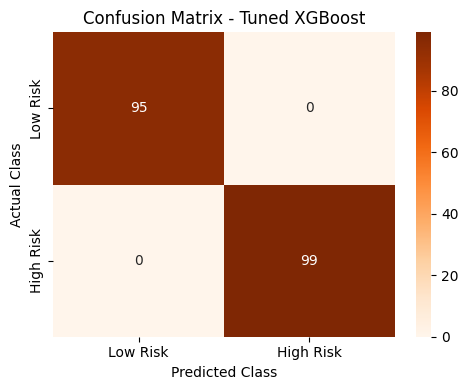

Tuned XGBoost AUC Score: 1.0


In [27]:
# Cell 4: Hyperparameter tuning for XGBoost

from xgboost import XGBClassifier

# Base XGBoost model
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Hyperparameter search space
xgb_params = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# RandomizedSearchCV setup
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_params,
    n_iter=15,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Train using only training data
xgb_random_search.fit(X_train_scaled, y_train)

# Best tuned model
best_xgb = xgb_random_search.best_estimator_

# Predictions
xgb_tuned_pred = best_xgb.predict(X_test_scaled)
xgb_tuned_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Evaluation
xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_pred, zero_division=0)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_pred, zero_division=0)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_pred, zero_division=0)
xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_prob)

# Store results
tuned_results.append({
    "Model": "Tuned XGBoost",
    "Accuracy": xgb_tuned_accuracy,
    "Precision": xgb_tuned_precision,
    "Recall": xgb_tuned_recall,
    "F1 Score": xgb_tuned_f1,
    "AUC Score": xgb_tuned_auc
})

tuned_roc_data["Tuned XGBoost"] = xgb_tuned_prob

print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

print("\nTuned XGBoost Classification Report:")
print(classification_report(y_test, xgb_tuned_pred, zero_division=0))

# Confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_tuned_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("Tuned XGBoost AUC Score:", round(xgb_tuned_auc, 4))

In [28]:
# Cell 5: Compare all tuned models

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    by="AUC Score",
    ascending=False
)

display(tuned_results_df)

best_tuned_model = tuned_results_df.iloc[0]["Model"]
best_tuned_auc = tuned_results_df.iloc[0]["AUC Score"]

print("Best Tuned Model:", best_tuned_model)
print("Best Tuned AUC Score:", round(best_tuned_auc, 4))

,Model,Accuracy,Precision,Recall,F1 Score,AUC Score
1,Tuned SVM,0.994845,0.99,1.000000,0.994975,1.000000
2,Tuned XGBoost,1.000000,1.00,1.000000,1.000000,1.000000
0,Tuned Decision Tree,0.989691,1.00,0.979798,0.989796,0.999575


Best Tuned Model: Tuned SVM
Best Tuned AUC Score: 1.0


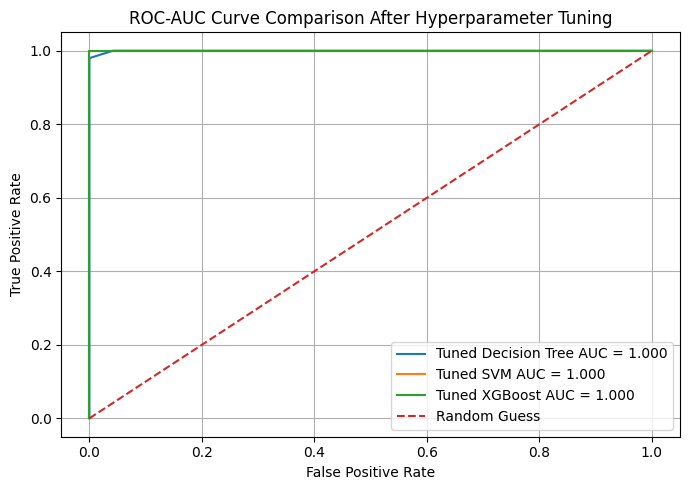

In [29]:
# Cell 6: Plot ROC-AUC curves for tuned models

plt.figure(figsize=(7, 5))

for model_name, y_probability in tuned_roc_data.items():

    fpr, tpr, thresholds = roc_curve(y_test, y_probability)
    auc_score = roc_auc_score(y_test, y_probability)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC = {auc_score:.3f}"
    )

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC-AUC Curve Comparison After Hyperparameter Tuning")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()